In [ ]:
# Run from the repository root so data/, scripts/, dashboard/, outputs/ paths resolve.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# SA-Error Detector: Accuracy Model
### Chapter 5 (Study 2): reproduces Section 3.2, Table 3, the SHAP driver analysis, and the parsimony / robustness checks (Section 3.5, Supplementary Table)

**Question.** Can a short window of pre-probe operator behaviour (gaze + manual control) predict whether the operator will *misjudge* the situation on the next probe?

**Outcome.** Binary situation-awareness (SA) error per probe: `Target_Accuracy == 0` (1 = incorrect response, the positive class).

**Modelling scope.** Perceptually demanding **Sign + Animal** probes only, **n = 439 probes, 37 operators**, matching the manuscript (Section 2.11). Speed probes are removed (the gaze target has no spatial variance); Name probes have no in-scene target and are kept only as a *pooled* robustness comparison.

**Data.** `route1…6_ml_ready.csv`, one row per probe, stacked into a single table. The 11 modelling features have no missing values.

---

### Packages, and what each is used for
| Package | Used for | Why |
|---|---|---|
| **pandas / numpy** | assembling the probe table, scaling dwell features | standard tabular handling |
| **xgboost** | the SA-error detector (gradient-boosted trees) | captures non-linear gaze × control interactions with shallow trees, which suit a rare-event, low-*n* behavioural problem |
| **scikit-learn** | nested operator-grouped cross-validation, grid search, baseline models (dummy / logistic / random forest), metrics | grouped splits stop operator-identity leakage; nested CV gives an unbiased performance estimate |
| **shap** | out-of-fold `TreeExplainer` attributions + cross-fold ranking stability | signed, additive, model-agnostic attribution, preferred over gain importance, and its stability across folds is reported rather than a single split |
| **statsmodels** | variance inflation factors | collinearity screen on the feature set (Supplementary Table) |
| **matplotlib** | SHAP summary / dependence plots, PR curve, learning curve | figures |

### Why these methods
- **Operator-grouped cross-validation.** Every fold keeps an operator's probes together, so the detector is always scored on operators it has never seen, the honest test for a monitor that must generalise to new personnel.
- **PR-AUC as the primary metric.** SA errors are the minority outcome; precision–recall area is anchored to prevalence and summarises the recall/precision trade-off across all thresholds, whereas overall accuracy and macro-F1 are inflated by the majority (correct) class.
- **Nested cross-validation.** Hyperparameters are chosen in an inner loop and scored on an untouched outer fold, so the reported PR-AUC / ROC-AUC is not optimistically biased by tuning on the test data. The final, interpreted model uses the configuration the inner loop selected most often.
- **Class weighting (`scale_pos_weight`), not resampling.** Re-weights the rare error class in place, avoiding the synthetic rows SMOTE would inject into a small behavioural sample.
- **Threshold selection on training folds only.** The operating threshold is fixed on out-of-fold training predictions and applied once to the untouched holdout, so no metric is tuned on the data it is reported on.

*Environment: Python 3 with pandas, numpy, scikit-learn, xgboost, shap, statsmodels, matplotlib. Run top-to-bottom; deterministic (`random_state=42`).*

In [1]:
# ===========================================================================
# SA-ERROR DETECTOR (accuracy model), Chapter 5, Study 2
# ===========================================================================
# Reproduces Section 3.2 (predicting SA errors), the nested-CV model comparison
# (Table 3), the out-of-fold SHAP driver analysis, and the parsimony/robustness
# checks (Section 3.5; Supplementary Table).
#
# Outcome:  binary SA error per probe (Target_Accuracy == 0; 1 = incorrect).
# Scope:    perceptually demanding Sign + Animal probes (n = 439, 37 operators).
#           Speed probes are purged (no gaze variance); Name probes have no
#           in-scene target and are retained only as a pooled robustness arm.
# Evaluation: operator-grouped nested cross-validation (GroupKFold over
#           Participant_ID), so every estimate is on held-out operators; the
#           reported metric is out-of-fold PR-AUC against the base rate.
# ===========================================================================
import pandas as pd
import numpy as np
import os
from collections import Counter
import xgboost as xgb
from sklearn.metrics import (precision_recall_curve, classification_report,
                             accuracy_score, roc_auc_score, average_precision_score,
                             recall_score)
from sklearn.model_selection import (GroupShuffleSplit, GroupKFold, GridSearchCV,
                                      cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD AND STACK ALL ROUTES
# ==========================================
print("Hunting for Route Datasets...")
data_frames = []
for i in range(1, 7):
    filename = f"data/route{i}_ml_ready.csv"
    if os.path.exists(filename):
        print(f"   > Found {filename}! Adding to master dataset...")
        temp_df = pd.read_csv(filename)
        temp_df['Route'] = i
        data_frames.append(temp_df)
    else:
        print(f"   > Missing {filename}. Skipping.")

if not data_frames:
    raise FileNotFoundError("No route datasets found. Please check your file paths.")

df = pd.concat(data_frames, ignore_index=True)
print(f"\nMaster Dataset Assembled: {len(df)} total target events.")

# --- Missing-value handling -------------------------------------------------
# NOTE: the 11 modelling features below contain no missing values in the raw
# data, so model results are unaffected by imputation. The blanket fillna(0.0)
# only affects non-modelling columns (e.g. Prev_Q_After_* and route-specific
# distractors that are structurally absent on a given route); for those,
# 0 = "object not present / no prior question", the correct semantic value.
df = df.fillna(0.0)

# ==========================================
# 1.5 ZERO-VARIANCE PURGE (Remove 'Speed' Queries)
# ==========================================
if 'Question_Type' in df.columns:
    initial_len = len(df)
    df = df[~df['Question_Type'].str.contains('speed', case=False, na=False)]
    removed_count = initial_len - len(df)
    print(f"Purged {removed_count} 'Speed' QUERIES (0 variance constraint).")
    print(f"   New Cleaned Dataset Size: {len(df)} target events.")
    # NB: the 'speed' DISTRACTOR feature (the speedometer dwell) is a legitimate
    # constant gaze target and is intentionally retained.
else:
    print("Warning: 'Question_Type' column not found. Could not filter speed queries.")

# ==========================================
# 2. FEATURE ENGINEERING: CONTEXT MASKS
# ==========================================
print("\nCreating context masks and scaling dwells...")
df['Is_First_Event'] = np.where(df['Event'] == 1, 1, 0)

before_dwell_cols = [col for col in df.columns if 'Before_Raw_Dwell' in col]
for col in before_dwell_cols:
    new_col_name = col.replace('Raw_Dwell', 'Dwell_Proportion')
    df[new_col_name] = df[col] / 5.0

# === Road-gaze operationalisation and angular saccade units ===
# (1) MODELLING road-gaze proportion is the driver-monitoring "eyes-on-road" analog:
#     gaze on the forward driving feed, off only the physical off-screen references
#     (route map, name clipboard). The speed readout sat on-screen beside the road and
#     is retained as on-scene. The former measure (1 - dwell on ALL coded objects) is
#     kept as 'Diffuse_Gaze_Pct' for the descriptive query-type contrast only (it is
#     the near-complement of target dwell and carries no independent SA signal).
for _p in ['Before', 'During']:
    _off = [c for c in [f'{_p}_Raw_Dwell_map_Distractor', f'{_p}_Raw_Dwell_name_Distractor'] if c in df.columns]
    if f'{_p}_Road_Gaze_Pct' in df.columns and _off:
        _den = 5.0 if _p == 'Before' else df['Target_Latency'].clip(lower=1e-6)
        df[f'{_p}_Diffuse_Gaze_Pct'] = df[f'{_p}_Road_Gaze_Pct']
        df[f'{_p}_Road_Gaze_Pct'] = (1 - df[_off].sum(axis=1) / _den).clip(0, 1)
# (2) Saccadic amplitude/velocity to angular units. The Pupil Cloud export is linear in
#     visual angle (0.0746 deg/px; ~13.4 px/deg, SD 0.6%); a constant rescale leaves
#     tree-model and standardised-GLMM results identical and only changes reported units.
_DEG_PER_PX = 0.074562
for _p in ['Before', 'During']:
    for _b, _n in [(f'{_p}_Scanpath_Rate_px_s', f'{_p}_Scanpath_Rate_deg_s'),
                   (f'{_p}_Mean_Saccadic_Velocity', f'{_p}_Mean_Saccadic_Velocity_deg_s')]:
        if _b in df.columns:
            df[_n] = df[_b] * _DEG_PER_PX
df = df.copy()  # de-fragment after column inserts

MASTER_OUT_FILE = "data/master_routes_1_to_6_combined.csv"
df.to_csv(MASTER_OUT_FILE, index=False)
print(f"Master dataset saved to disk as '{MASTER_OUT_FILE}'.")

# ==========================================
# 1.6 PRIMARY MODELLING SCOPE: Sign + Animal only
# ==========================================
# The manuscript scopes all three detectors to the perceptually demanding
# Sign + Animal queries (n=439). Name is excluded from the PRIMARY model (no
# in-scene target -> target-object dwell does not operate) and retained only as
# a pooled-set robustness comparison.
df_pooled = df.copy()                                   # Sign + Animal + Name (Speed already purged)
df = df[df['Question_Type'].isin(['Sign', 'Animal'])].copy()
_yacc = (1 - df['Target_Accuracy'])
print(f"\nPRIMARY SCOPE (Sign + Animal): {len(df)} events, "
      f"{df['Participant_ID'].nunique()} operators, "
      f"{int(_yacc.sum())} incorrect ({_yacc.mean():.1%}).")


/Users/Ryan/EyeTrack/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hunting for Route Datasets...
   > Found route1_ml_ready.csv! Adding to master dataset...
   > Found route2_ml_ready.csv! Adding to master dataset...
   > Found route3_ml_ready.csv! Adding to master dataset...
   > Found route4_ml_ready.csv! Adding to master dataset...
   > Found route5_ml_ready.csv! Adding to master dataset...
   > Found route6_ml_ready.csv! Adding to master dataset...

Master Dataset Assembled: 659 total target events.
Purged 147 'Speed' QUERIES (0 variance constraint).
   New Cleaned Dataset Size: 512 target events.

Creating context masks and scaling dwells...
Master dataset saved to disk as 'master_routes_1_to_6_combined.csv'.

PRIMARY SCOPE (Sign + Animal): 439 events, 37 operators, 95 incorrect (21.6%).


In [2]:
# ==========================================
# 3. PRIMARY FEATURE SET: reduced "Gaze + Control" (11 features)
# ==========================================
# Parsimony analysis (Section 3.5; Supplementary Table) showed the full
# 16-feature candidate set is never the best model: dropping the individual-difference
# and (clean) distractor-dwell blocks, which were at/below chance for every outcome,
# costs nothing for accuracy/confidence and IMPROVES freeze detection. We therefore
# adopt the reduced theory-grouped set as PRIMARY, identical across all three detectors.
#   Gaze/attention (5): saccade rate, target-object dwell, saccadic velocity,
#                       road-gaze %, scanpath rate
#   Manual-control (6): steer var, speed var, major SRR, fine SRR, TRR, zero-throttle %
print("Assembling REDUCED 'Gaze+Control' primary feature set (11 features)...")
candidate_features = [
    # --- visual attention / oculomotor (eye-tracking) ---
    'Before_Saccade_Rate_Hz', 'Before_Dwell_Proportion_Target_Object',
    'Before_Mean_Saccadic_Velocity_deg_s', 'Before_Road_Gaze_Pct', 'Before_Scanpath_Rate_deg_s',
    # --- manual-control instability (telemetry) ---
    'Before_Steer_Variance', 'Before_Speed_Variance', 'Before_Major_SRR',
    'Before_Fine_SRR', 'Before_TRR', 'Before_Zero_Throttle_Pct',
]
feature_cols = [f for f in candidate_features if f in df.columns]
X = df[feature_cols]
y = 1 - df['Target_Accuracy']        # 1 = Incorrect SA Response (positive class)
groups = df['Participant_ID']

print(f"   Features (reduced): {len(feature_cols)} | Events: {len(X)} | Participants: {groups.nunique()}")
print(f"   Positive (incorrect SA) events: {int(y.sum())} ({y.mean():.1%}) | "
      f"positive events-per-feature: {y.sum()/len(feature_cols):.1f}")
print("   NOTE: exploratory; rankings validated by out-of-fold SHAP stability, not single fits.")


Assembling REDUCED 'Gaze+Control' primary feature set (11 features)...
   Features (reduced): 11 | Events: 439 | Participants: 37
   Positive (incorrect SA) events: 95 (21.6%) | positive events-per-feature: 8.6
   NOTE: exploratory; rankings validated by out-of-fold SHAP stability, not single fits.


In [3]:
# ==========================================
# 4. COLLINEARITY AUDIT (Variance Inflation Factor)
# ==========================================
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\nAUDITING MODEL FOR COLLINEARITY (VIF)...")
print("NOTE (thesis): VIF treats the 513 rows as independent; they are actually "
      "clustered within 37 participants. Report VIF as a collinearity screen only, "
      "not as an independent-sample diagnostic.")

X_vif = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

print("\n--- Variance Inflation Factors ---")
print(vif_data.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

high_vif = vif_data[vif_data["VIF"] > 5.0]['Feature'].tolist()
if high_vif:
    print(f"\nWARNING: High collinearity detected in: {high_vif}")
else:
    print("\nVIF Check Passed: features represent distinct constructs.")



AUDITING MODEL FOR COLLINEARITY (VIF)...
NOTE (thesis): VIF treats the 513 rows as independent; they are actually clustered within 37 participants. Report VIF as a collinearity screen only, not as an independent-sample diagnostic.



--- Variance Inflation Factors ---
                              Feature  VIF
           Before_Scanpath_Rate_deg_s 3.98
               Before_Saccade_Rate_Hz 2.66
  Before_Mean_Saccadic_Velocity_deg_s 1.86
                     Before_Major_SRR 1.68
                           Before_TRR 1.65
                      Before_Fine_SRR 1.55
                Before_Speed_Variance 1.49
             Before_Zero_Throttle_Pct 1.32
Before_Dwell_Proportion_Target_Object 1.25
                 Before_Road_Gaze_Pct 1.17
                Before_Steer_Variance 1.17

VIF Check Passed: features represent distinct constructs.


In [4]:
# ==========================================
# 5. NESTED CROSS-VALIDATION: BASELINE MODEL COMPARISON
# ==========================================
print("\n" + "="*65 + "\nNESTED CV: BASELINE COMPARISON\n" + "="*65)
outer_cv, inner_cv = GroupKFold(n_splits=5), GroupKFold(n_splits=4)
comparison_results = {}
selected_params = {}        # capture inner-loop winners per outer fold

model_configs = {
    'Dummy': {'pipeline': Pipeline([('imputer', SimpleImputer(strategy='median')),
              ('model', DummyClassifier(strategy='stratified', random_state=42))]), 'params': {}},
    'LogReg': {'pipeline': Pipeline([('imputer', SimpleImputer(strategy='median')),
              ('scaler', StandardScaler()),
              ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))]),
              'params': {'model__C': [0.1, 1]}},
    'Random Forest': {'pipeline': Pipeline([('imputer', SimpleImputer(strategy='median')),
              ('model', RandomForestClassifier(class_weight='balanced', random_state=42))]),
              'params': {'model__max_depth': [3, 5]}},
}

for name, config in model_configs.items():
    print(f" > Testing: {name}...")
    outer_roc, outer_pr, fold_params = [], [], []
    for train_idx, test_idx in outer_cv.split(X, y, groups):
        if len(np.unique(y.iloc[test_idx])) < 2:
            continue
        gs = GridSearchCV(config['pipeline'], config['params'], cv=inner_cv,
                          scoring='roc_auc', n_jobs=-1)
        gs.fit(X.iloc[train_idx], y.iloc[train_idx], groups=groups.iloc[train_idx])
        preds = gs.predict_proba(X.iloc[test_idx])[:, 1]
        outer_roc.append(roc_auc_score(y.iloc[test_idx], preds))
        outer_pr.append(average_precision_score(y.iloc[test_idx], preds))
        fold_params.append(gs.best_params_)
    comparison_results[name] = {
        'ROC-AUC_mean': np.mean(outer_roc), 'ROC-AUC_std': np.std(outer_roc),
        'PR-AUC_mean': np.mean(outer_pr), 'PR-AUC_std': np.std(outer_pr)}
    selected_params[name] = fold_params

# --- XGBoost: all hyperparameters (incl. n_estimators) are validated inside the nested CV ---
print(" > Testing: XGBoost...")
xgb_grid = {'max_depth': [2, 3], 'learning_rate': [0.03, 0.1], 'n_estimators': [100, 200]}
xgb_outer_roc, xgb_outer_pr, xgb_fold_params = [], [], []
for train_idx, test_idx in outer_cv.split(X, y, groups):
    if len(np.unique(y.iloc[test_idx])) < 2:
        continue
    y_tr = y.iloc[train_idx]
    weight = y_tr.value_counts().get(0, 1) / y_tr.value_counts().get(1, 1)
    gs = GridSearchCV(
        xgb.XGBClassifier(scale_pos_weight=weight, eval_metric='logloss', random_state=42),
        xgb_grid, cv=inner_cv, scoring='roc_auc', n_jobs=-1)
    gs.fit(X.iloc[train_idx], y_tr, groups=groups.iloc[train_idx])
    preds = gs.predict_proba(X.iloc[test_idx])[:, 1]
    xgb_outer_roc.append(roc_auc_score(y.iloc[test_idx], preds))
    xgb_outer_pr.append(average_precision_score(y.iloc[test_idx], preds))
    xgb_fold_params.append(gs.best_params_)
comparison_results['XGBoost'] = {
    'ROC-AUC_mean': np.mean(xgb_outer_roc), 'ROC-AUC_std': np.std(xgb_outer_roc),
    'PR-AUC_mean': np.mean(xgb_outer_pr), 'PR-AUC_std': np.std(xgb_outer_pr)}
selected_params['XGBoost'] = xgb_fold_params

print(f"\n{'Model':<15} {'ROC-AUC':>20} {'PR-AUC':>20}")
for name, res in comparison_results.items():
    print(f"{name:<15} {res['ROC-AUC_mean']:.3f} +/- {res['ROC-AUC_std']:.3f}    "
          f"{res['PR-AUC_mean']:.3f} +/- {res['PR-AUC_std']:.3f}")



NESTED CV: BASELINE COMPARISON
 > Testing: Dummy...


 > Testing: LogReg...
 > Testing: Random Forest...
 > Testing: XGBoost...

Model                        ROC-AUC               PR-AUC
Dummy           0.480 +/- 0.060    0.219 +/- 0.043
LogReg          0.638 +/- 0.065    0.346 +/- 0.056
Random Forest   0.674 +/- 0.063    0.337 +/- 0.082
XGBoost         0.676 +/- 0.041    0.375 +/- 0.085


In [5]:
# ==========================================
# 5b. DERIVE FINAL HYPERPARAMETERS FROM THE NESTED CV
# ==========================================
# Instead of hardcoding hyperparameters, we adopt the configuration the inner
# loop selected most often across the outer folds, and report the distribution.
print("\n" + "="*65 + "\nHYPERPARAMETER SELECTION (XGBoost, across outer folds)\n" + "="*65)
for fp in xgb_fold_params:
    print("   fold ->", fp)

param_counts = Counter(tuple(sorted(p.items())) for p in xgb_fold_params)
modal_key, modal_n = param_counts.most_common(1)[0]
FINAL_XGB_PARAMS = dict(modal_key)
print(f"\nMODAL CONFIG selected in {modal_n}/{len(xgb_fold_params)} outer folds:")
print(f"   {FINAL_XGB_PARAMS}")
print("This validated configuration is used for the final model, SHAP, and the "
      "holdout evaluation below, the reported model and the interpreted model "
      "are now identical.")

def make_xgb(y_train_subset, **extra):
    """Build an XGBoost classifier with the validated config and a
    class weight computed ONLY from the supplied training labels."""
    w = y_train_subset.value_counts().get(0, 1) / y_train_subset.value_counts().get(1, 1)
    params = dict(FINAL_XGB_PARAMS)
    params.update(extra)
    return xgb.XGBClassifier(scale_pos_weight=w, eval_metric='logloss',
                             random_state=42, **params)



HYPERPARAMETER SELECTION (XGBoost, across outer folds)
   fold -> {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
   fold -> {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
   fold -> {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
   fold -> {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}
   fold -> {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}

MODAL CONFIG selected in 3/5 outer folds:
   {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
This validated configuration is used for the final model, SHAP, and the holdout evaluation below, the reported model and the interpreted model are now identical.


In [6]:
# ==========================================
# 6. FINAL MODEL + HOLDOUT (classification threshold chosen on TRAIN only)
# ==========================================
print("\nTraining Final Model (validated hyperparameters)...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

final_model = make_xgb(y_train)
final_model.fit(X_train, y_train)

# --- Select the F1-optimal threshold WITHOUT touching the holdout ---
# Out-of-fold predicted probabilities on the TRAINING participants only.
thr_cv = GroupKFold(n_splits=4)
oof_proba_train = cross_val_predict(
    make_xgb(y_train), X_train, y_train,
    groups=groups_train, cv=thr_cv, method='predict_proba')[:, 1]

prec_tr, rec_tr, thr_tr = precision_recall_curve(y_train, oof_proba_train)
with np.errstate(invalid='ignore', divide='ignore'):
    denom = prec_tr[:-1] + rec_tr[:-1]
    f1_tr = np.where(denom == 0, 0, 2 * prec_tr[:-1] * rec_tr[:-1] / denom)
best_idx_tr = int(np.argmax(f1_tr))
BEST_THRESHOLD = float(thr_tr[best_idx_tr])   # LOCKED IN: never re-tuned on test

print(f"\nF1-OPTIMAL THRESHOLD (selected on TRAIN out-of-fold): {BEST_THRESHOLD:.4f}")
print(f"   Train OOF F1 at this threshold: {f1_tr[best_idx_tr]:.4f}")



Training Final Model (validated hyperparameters)...

F1-OPTIMAL THRESHOLD (selected on TRAIN out-of-fold): 0.3178
   Train OOF F1 at this threshold: 0.4345



Generating OUT-OF-FOLD SHAP values across all CV folds...

--- SHAP RANKING STABILITY (lower mean rank = more important) ---
                              Feature  Mean_Rank  Rank_Std
Before_Dwell_Proportion_Target_Object       1.00      0.00
                Before_Speed_Variance       2.00      0.00
           Before_Scanpath_Rate_deg_s       4.00      1.26
  Before_Mean_Saccadic_Velocity_deg_s       5.60      1.20
                 Before_Road_Gaze_Pct       5.60      2.06
                Before_Steer_Variance       6.00      1.41
                      Before_Fine_SRR       6.20      2.40
               Before_Saccade_Rate_Hz       7.20      2.32
                     Before_Major_SRR       8.60      1.85
             Before_Zero_Throttle_Pct       9.00      0.63
                           Before_TRR      10.80      0.40


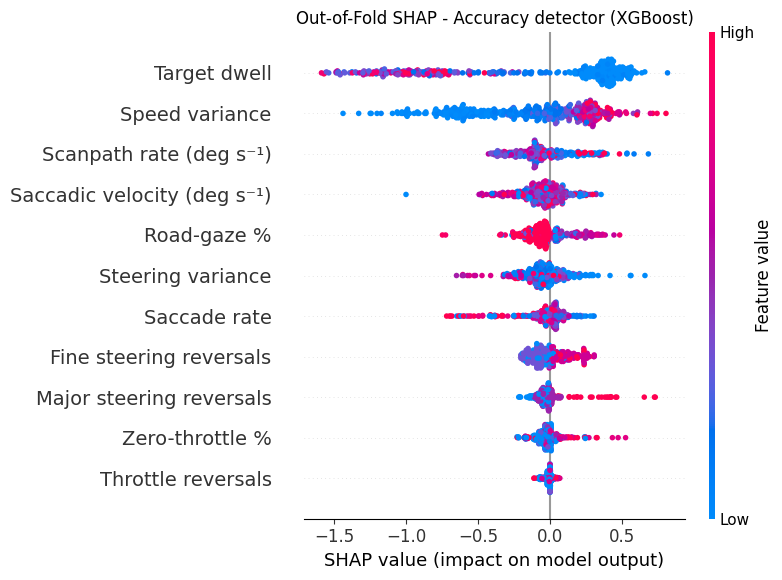

<Figure size 800x500 with 0 Axes>

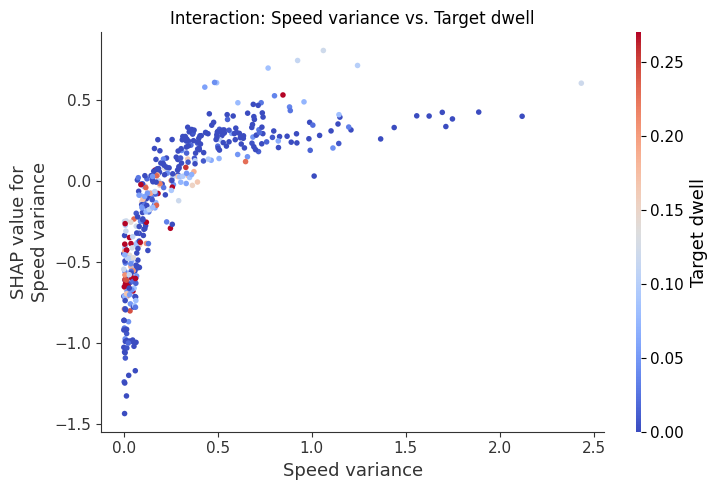

<Figure size 800x500 with 0 Axes>

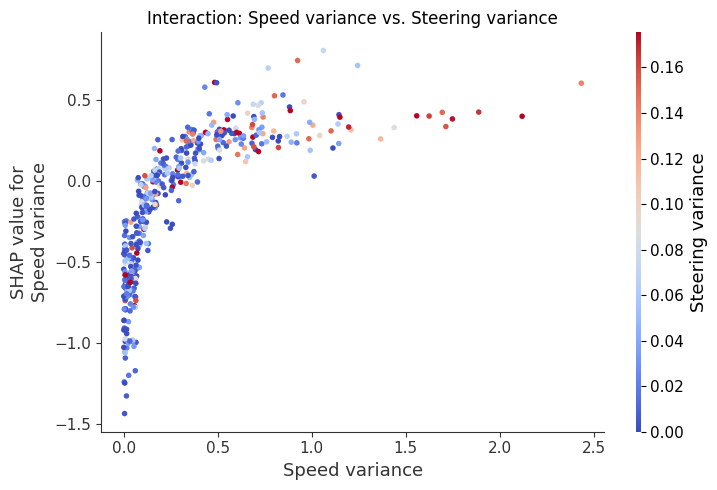

In [7]:
# ==========================================
# 7. SHAP ANALYSIS (out-of-fold across all participants + ranking stability)
# ==========================================
print("\nGenerating OUT-OF-FOLD SHAP values across all CV folds...")
oof_shap_list, oof_X_list, fold_rankings = [], [], []
for tr_idx, te_idx in outer_cv.split(X, y, groups):
    m = make_xgb(y.iloc[tr_idx])
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    sv = shap.TreeExplainer(m).shap_values(X.iloc[te_idx])
    oof_shap_list.append(sv)
    oof_X_list.append(X.iloc[te_idx])
    mean_abs = np.abs(sv).mean(axis=0)             # per-fold importance
    order = np.argsort(mean_abs)[::-1]
    ranks = np.empty(len(order), dtype=int); ranks[order] = np.arange(1, len(order) + 1)
    fold_rankings.append(ranks)

shap_oof = np.vstack(oof_shap_list)
X_oof = pd.concat(oof_X_list)
y_oof = y.loc[X_oof.index]

# --- Ranking stability across folds (is the SHAP story robust?) ---
fold_rankings = np.array(fold_rankings)
stability = (pd.DataFrame({'Feature': X.columns,
                           'Mean_Rank': fold_rankings.mean(axis=0),
                           'Rank_Std': fold_rankings.std(axis=0)})
             .sort_values('Mean_Rank'))
print("\n--- SHAP RANKING STABILITY (lower mean rank = more important) ---")
print(stability.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# --- Aggregated SHAP summary plot ---
PRETTY = {'Before_Saccade_Rate_Hz': 'Saccade rate',
          'Before_Dwell_Proportion_Target_Object': 'Target dwell',
          'Before_Mean_Saccadic_Velocity_deg_s': 'Saccadic velocity (deg s⁻¹)',
          'Before_Road_Gaze_Pct': 'Road-gaze %', 'Before_Scanpath_Rate_deg_s': 'Scanpath rate (deg s⁻¹)',
          'Before_Steer_Variance': 'Steering variance', 'Before_Speed_Variance': 'Speed variance',
          'Before_Major_SRR': 'Major steering reversals', 'Before_Fine_SRR': 'Fine steering reversals',
          'Before_TRR': 'Throttle reversals', 'Before_Zero_Throttle_Pct': 'Zero-throttle %'}
labels = [PRETTY.get(c, c.replace('Before_', '').replace('Dwell_Proportion_', 'Dwell %: ')) for c in X_oof.columns]
X_oof_clean = X_oof.copy(); X_oof_clean.columns = labels
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_oof, X_oof_clean, show=False)
ax = plt.gca()
ax.tick_params(axis='y', labelsize=14)                 # feature-name labels
ax.tick_params(axis='x', labelsize=12)
ax.set_xlabel('SHAP value (impact on model output)', fontsize=13)
cb = plt.gcf().axes[-1]; cb.tick_params(labelsize=11); cb.set_ylabel(cb.get_ylabel(), fontsize=12)
plt.title("Out-of-Fold SHAP - Accuracy detector (XGBoost)", fontsize=12)
plt.tight_layout(); plt.show(); plt.close()

# --- Dependence plots (interactions) ---
dependence_specs = [
    ("Speed variance", "Target dwell"),
    ("Speed variance", "Steering variance"),
]
for main_feat, inter in dependence_specs:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(main_feat, shap_oof, X_oof_clean,
                         interaction_index=inter, show=False,
                         cmap=plt.get_cmap("coolwarm"))
    plt.title(f"Interaction: {main_feat} vs. {inter}", fontsize=12)
    plt.tight_layout(); plt.show(); plt.close()

REPORTED: out-of-fold detection (all participants)
OOF PR-AUC = 0.336  95% CI [0.246, 0.460]  (chance 0.216; lift 1.6x)
OOF ROC-AUC = 0.680 (SD 0.044)  [per-fold mean, as reported]

--------------------------------------------------
SECONDARY CHECK: single 20% holdout (illustrative; n=96, 24 positive)
--------------------------------------------------
Holdout ROC-AUC = 0.629   PR-AUC = 0.342  (chance 0.250)
Positive class (incorrect SA) at pre-committed threshold 0.318: recall=0.67  precision=0.32  F1=0.43  (one reference point, not the target metric)


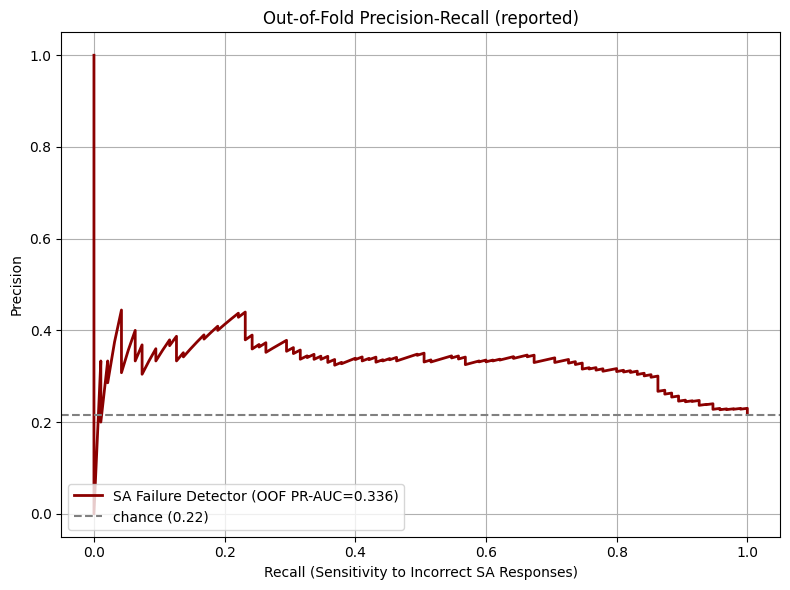

In [8]:
# ==========================================
# 8. MODEL EVALUATION: out-of-fold (reported) + single holdout (illustrative)
# ==========================================
# For a rare event the REPORTED metric is the out-of-fold PR-AUC vs base rate
# (it summarises the precision/recall trade-off across all thresholds, anchored
# to prevalence) plus the operating-point table (recall-tunable, precision-
# bounded; see the threshold-lever cell). Accuracy and macro-averaged F1 are NOT
# reported: under heavy class imbalance they mislead (predicting the majority
# class scores deceptively well), and F1 fixes a single operating point and
# weights precision and recall equally, whereas a safety detector usually weights
# recall above precision.
from sklearn.metrics import precision_score, recall_score, f1_score

# --- REPORTED: out-of-fold PR-AUC across all participants (grouped CV) ---
oof_proba = cross_val_predict(make_xgb(y), X, y, groups=groups,
                              cv=GroupKFold(5), method='predict_proba')[:, 1]
oof_ap, chance = average_precision_score(y, oof_proba), y.mean()
rng = np.random.default_rng(42); pids = groups.unique(); gv = groups.values; boot = []
for _ in range(400):
    s = rng.choice(pids, len(pids), replace=True)
    idx = np.concatenate([np.where(gv == p)[0] for p in s])
    if y.iloc[idx].nunique() < 2:
        continue
    boot.append(average_precision_score(y.iloc[idx], oof_proba[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print("="*50 + "\nREPORTED: out-of-fold detection (all participants)\n" + "="*50)
print(f"OOF PR-AUC = {oof_ap:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (chance {chance:.3f}; lift {oof_ap/chance:.1f}x)")
_froc = []
for _tr, _te in GroupKFold(5).split(X, y, groups):
    _m = make_xgb(y.iloc[_tr]); _m.fit(X.iloc[_tr], y.iloc[_tr])
    if y.iloc[_te].nunique() > 1:
        _froc.append(roc_auc_score(y.iloc[_te], _m.predict_proba(X.iloc[_te])[:, 1]))
print(f"OOF ROC-AUC = {np.mean(_froc):.3f} (SD {np.std(_froc):.3f})  [per-fold mean, as reported]")

# --- SECONDARY (illustrative only): single 20% holdout, small + noisy ---
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_pred_proba >= BEST_THRESHOLD).astype(int)
print("\n" + "-"*50 + f"\nSECONDARY CHECK: single 20% holdout (illustrative; n={len(y_test)}, "
      f"{int(y_test.sum())} positive)\n" + "-"*50)
print(f"Holdout ROC-AUC = {roc_auc_score(y_test, y_pred_proba):.3f}   "
      f"PR-AUC = {average_precision_score(y_test, y_pred_proba):.3f}  (chance {y_test.mean():.3f})")
print(f"Positive class (incorrect SA) at pre-committed threshold {BEST_THRESHOLD:.3f}: "
      f"recall={recall_score(y_test, y_pred_optimal, zero_division=0):.2f}  "
      f"precision={precision_score(y_test, y_pred_optimal, zero_division=0):.2f}  "
      f"F1={f1_score(y_test, y_pred_optimal, zero_division=0):.2f}  (one reference point, not the target metric)")

# Out-of-fold PR curve (the reported trade-off)
precisions, recalls, _ = precision_recall_curve(y, oof_proba)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label=f'SA Failure Detector (OOF PR-AUC={oof_ap:.3f})', color='darkred', lw=2)
plt.axhline(chance, color='gray', ls='--', label=f'chance ({chance:.2f})')
plt.xlabel('Recall (Sensitivity to Incorrect SA Responses)'); plt.ylabel('Precision')
plt.title('Out-of-Fold Precision-Recall (reported)'); plt.legend(loc='lower left')
plt.grid(True); plt.tight_layout(); plt.show(); plt.close()



--- TOP PREDICTIVE FEATURES (final validated model) ---
                              Feature  Importance_Percentage
Before_Dwell_Proportion_Target_Object                 19.25%
                Before_Speed_Variance                 11.14%
                Before_Steer_Variance                 10.60%
           Before_Scanpath_Rate_deg_s                 10.17%
               Before_Saccade_Rate_Hz                  9.50%
                      Before_Fine_SRR                  9.18%
  Before_Mean_Saccadic_Velocity_deg_s                  8.56%
             Before_Zero_Throttle_Pct                  8.19%
                     Before_Major_SRR                  7.08%
                 Before_Road_Gaze_Pct                  6.33%


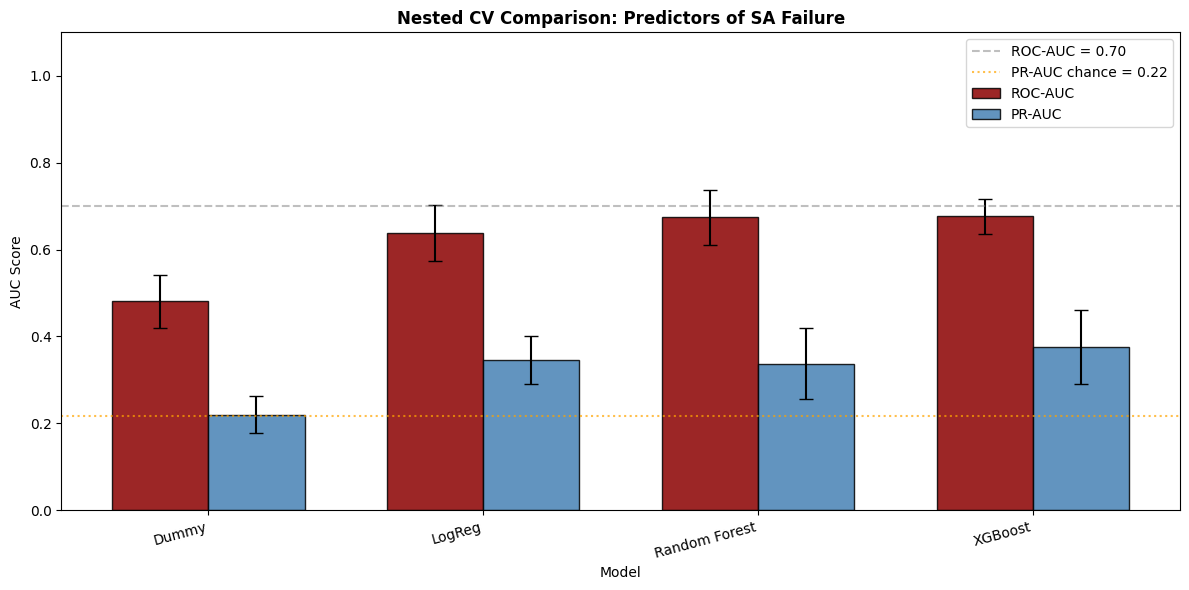

In [9]:
# ==========================================
# 9. FEATURE IMPORTANCES & MODEL-COMPARISON CHART
# ==========================================
print("\n--- TOP PREDICTIVE FEATURES (final validated model) ---")
fi = pd.DataFrame({'Feature': X_test.columns,
                   'Importance_Percentage': final_model.feature_importances_ * 100})
fi = fi[fi['Importance_Percentage'] > 0].sort_values('Importance_Percentage', ascending=False)
print(fi.to_string(index=False, float_format=lambda x: f"{x:.2f}%"))

model_names = list(comparison_results.keys())
roc_means = [comparison_results[m]['ROC-AUC_mean'] for m in model_names]
roc_stds  = [comparison_results[m]['ROC-AUC_std']  for m in model_names]
pr_means  = [comparison_results[m]['PR-AUC_mean']  for m in model_names]
pr_stds   = [comparison_results[m]['PR-AUC_std']   for m in model_names]
xpos = np.arange(len(model_names)); width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(xpos - width/2, roc_means, width, yerr=roc_stds, capsize=5, label='ROC-AUC',
       color='darkred', alpha=0.85, edgecolor='black')
ax.bar(xpos + width/2, pr_means, width, yerr=pr_stds, capsize=5, label='PR-AUC',
       color='steelblue', alpha=0.85, edgecolor='black')
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='ROC-AUC = 0.70')
ax.axhline(y=y.mean(), color='orange', linestyle=':', alpha=0.7,
           label=f'PR-AUC chance = {y.mean():.2f}')
ax.set_xlabel('Model'); ax.set_ylabel('AUC Score')
ax.set_title('Nested CV Comparison: Predictors of SA Failure', fontweight='bold')
ax.set_xticks(xpos); ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(); ax.set_ylim(0, 1.1); plt.tight_layout(); plt.show(); plt.close()


Estimating learning curve (grouped CV at each sample size)...
   n=10: ROC-AUC = 0.627 +/- 0.074
   n=15: ROC-AUC = 0.606 +/- 0.061
   n=20: ROC-AUC = 0.608 +/- 0.051
   n=25: ROC-AUC = 0.618 +/- 0.027
   n=30: ROC-AUC = 0.627 +/- 0.028
   n=37: ROC-AUC = 0.680 +/- 0.000
n=37 (repeated shuffled grouped CV, 20 partitions): ROC-AUC = 0.643 +/- 0.017


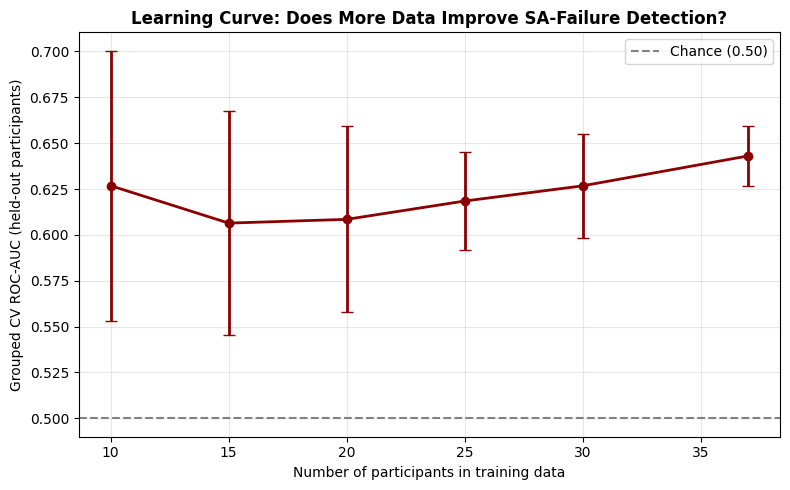


Still rising -> data-limited (scaling promising). Flat -> signal-limited.


In [10]:
# ==========================================
# 10. LEARNING CURVE: does MORE DATA help? (self-contained: curve + fair n=37 bar)
# ==========================================
# Builds the curve AND the fair n=37 error bar in ONE cell so there is no cross-cell
# dependency. Uses X / y / groups / make_xgb from earlier cells.
unique_pids = groups.unique(); n_total = len(unique_pids)
sample_sizes = [s for s in [10, 15, 20, 25, 30, n_total] if s <= n_total]
N_REPEATS = 8
rng = np.random.default_rng(42)
lc_mean, lc_std = [], []
print("Estimating learning curve (grouped CV at each sample size)...")
for s in sample_sizes:
    reps = 1 if s == n_total else N_REPEATS
    rep_scores = []
    for _ in range(reps):
        pids = rng.choice(unique_pids, size=s, replace=False)
        mask = groups.isin(pids).values
        Xs, ys, gs_ = X[mask], y[mask], groups[mask]
        if ys.nunique() < 2:
            continue
        cv = GroupKFold(n_splits=min(5, s)); fa = []
        for tr, te in cv.split(Xs, ys, gs_):
            if len(np.unique(ys.iloc[te])) < 2:
                continue
            mdl = make_xgb(ys.iloc[tr]); mdl.fit(Xs.iloc[tr], ys.iloc[tr])
            fa.append(roc_auc_score(ys.iloc[te], mdl.predict_proba(Xs.iloc[te])[:, 1]))
        if fa:
            rep_scores.append(np.mean(fa))
    lc_mean.append(np.mean(rep_scores) if rep_scores else np.nan)
    lc_std.append(np.std(rep_scores) if rep_scores else np.nan)
    print(f"   n={s:>2}: ROC-AUC = {lc_mean[-1]:.3f} +/- {lc_std[-1]:.3f}")

# --- Fair error bar for the full-data (n=37) point: repeated shuffled grouped CV ---
def grouped_cv_auc(Xs, ys, gs_, n_splits=5, seed=0):
    pids = np.array(pd.unique(gs_)); r = np.random.default_rng(seed); r.shuffle(pids)
    folds = np.array_split(pids, n_splits); aucs = []
    for k in range(n_splits):
        te_mask = gs_.isin(set(folds[k])).values; tr_mask = ~te_mask
        if len(np.unique(ys[te_mask])) < 2 or ys[tr_mask].nunique() < 2:
            continue
        mdl = make_xgb(ys[tr_mask]); mdl.fit(Xs[tr_mask], ys[tr_mask])
        aucs.append(roc_auc_score(ys[te_mask], mdl.predict_proba(Xs[te_mask])[:, 1]))
    return np.mean(aucs) if aucs else np.nan

full_scores = [grouped_cv_auc(X, y, groups, n_splits=5, seed=r) for r in range(20)]
lc_mean[-1] = float(np.nanmean(full_scores)); lc_std[-1] = float(np.nanstd(full_scores))
print(f"n={n_total} (repeated shuffled grouped CV, 20 partitions): "
      f"ROC-AUC = {lc_mean[-1]:.3f} +/- {lc_std[-1]:.3f}")

plt.figure(figsize=(8, 5))
plt.errorbar(sample_sizes, lc_mean, yerr=lc_std, marker='o', capsize=4, color='darkred', lw=2)
plt.axhline(0.5, ls='--', color='gray', label='Chance (0.50)')
plt.xlabel('Number of participants in training data')
plt.ylabel('Grouped CV ROC-AUC (held-out participants)')
plt.title('Learning Curve: Does More Data Improve SA-Failure Detection?', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show(); plt.close()
print("\nStill rising -> data-limited (scaling promising). Flat -> signal-limited.")


In [11]:
# ==========================================
# 11. OPERATING POINT: dialling up SA-error detection (and its cost)
# ==========================================
# All evaluation is OUT-OF-FOLD (GroupKFold over participants) -> honest, no
# holdout tuning. Detection sensitivity is an operating-point / cost decision,
# not a free lunch: more recall (catching failures) costs precision (false alarms).
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

base_ratio = y.value_counts().get(0, 1) / y.value_counts().get(1, 1)   # balanced spw (~4)
cv5 = GroupKFold(n_splits=5)

def oof_proba(scale_pos_weight):
    mdl = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                            random_state=42, **FINAL_XGB_PARAMS)
    return cross_val_predict(mdl, X, y, groups=groups, cv=cv5,
                             method='predict_proba')[:, 1]

HDR = (f"{'Setting':<22}{'Thr':>6}{'Recall':>9}{'Precision':>11}"
       f"{'F1':>7}{'FalseAlarm':>12}{'Caught':>10}{'FAs':>7}")

def report_row(name, y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    far = fp / (fp + tn) if (fp + tn) else 0
    print(f"{name:<22}{thr:>6.2f}{recall_score(y_true, pred, zero_division=0):>9.2f}"
          f"{precision_score(y_true, pred, zero_division=0):>11.2f}"
          f"{f1_score(y_true, pred, zero_division=0):>7.2f}{far:>12.2f}"
          f"{str(int(tp))+'/'+str(int(tp+fn)):>10}{int(fp):>7}")

# ---- LEVER A: threshold sweep (fixed balanced model; no retraining) ----
print("=" * 84)
print("LEVER A: DECISION THRESHOLD (no retraining; just move along the PR curve)")
print("=" * 84)
proba_bal = oof_proba(base_ratio)
print(HDR)
for thr in [0.50, 0.40, 0.30, 0.20, 0.15, 0.10]:
    report_row(f"threshold={thr:.2f}", y, proba_bal, thr)
print(f"\n(Actual SA failures = {int(y.sum())}; actual correct = {int((y == 0).sum())})")
print("Lowering the threshold catches more failures (Recall up) at the price of")
print("more false alarms (Precision down). The model's ranking/AUC is unchanged.")

# ---- LEVER B: scale_pos_weight sweep (train-time emphasis), evaluated at thr=0.50 ----
print("\n" + "=" * 84)
print("LEVER B: scale_pos_weight (train-time emphasis on the rare failure class)")
print("=" * 84)
print(HDR)
for mult in [1, 2, 4, 8]:
    report_row(f"spw={base_ratio*mult:.1f} ({mult}x bal)", y, oof_proba(base_ratio*mult), 0.50)
print("\nRaising scale_pos_weight is largely EQUIVALENT to lowering the threshold:")
print("it shifts the operating point toward recall, it does not raise the AUC.")

LEVER A: DECISION THRESHOLD (no retraining; just move along the PR curve)
Setting                  Thr   Recall  Precision     F1  FalseAlarm    Caught    FAs
threshold=0.50          0.50     0.57       0.33   0.42        0.32     54/95    111
threshold=0.40          0.40     0.75       0.32   0.45        0.44     71/95    151
threshold=0.30          0.30     0.86       0.30   0.44        0.56     82/95    194
threshold=0.20          0.20     0.88       0.26   0.40        0.70     84/95    242
threshold=0.15          0.15     0.93       0.24   0.38        0.81     88/95    277
threshold=0.10          0.10     0.99       0.23   0.37        0.92     94/95    317

(Actual SA failures = 95; actual correct = 344)
Lowering the threshold catches more failures (Recall up) at the price of
more false alarms (Precision down). The model's ranking/AUC is unchanged.

LEVER B: scale_pos_weight (train-time emphasis on the rare failure class)
Setting                  Thr   Recall  Precision     F1  Fal

In [12]:
# ==========================================
# 12. ROBUSTNESS: PRIMARY (Sign + Animal) vs POOLED (Sign+Animal+Name)
# ==========================================
# Sign + Animal is the primary scope. This cell contrasts it with
# the broader pooled set (df_pooled, Name retained) as a robustness check,
# the manuscript's Supplementary Table framing. Name queries (reading a name-tag) are an
# easier, different task (incorrect rate ~10% vs ~21-23%) with no in-scene
# target, so pooling dilutes the leading predictor (target-object dwell).
from scipy.stats import spearmanr
from sklearn.model_selection import cross_val_predict
TGT = 'Before_Dwell_Proportion_Target_Object'; SPV = 'Before_Speed_Variance'
def clean(c):  # local def so cell is self-contained (no dependence on SHAP cell)
    return c.replace('Before_', '').replace('Dwell_Proportion_', 'Dwell %: ')

def _acc_subgroup(frame, mask, label):
    d = frame[mask]; Xs = d[feature_cols]; gs_ = d['Participant_ID']; ys = 1 - d['Target_Accuracy']
    rocs, sv_all, X_all, ranks = [], [], [], []
    for tr, te in GroupKFold(5).split(Xs, ys, gs_):
        if ys.iloc[tr].nunique() < 2 or ys.iloc[te].nunique() < 2:
            continue
        m = make_xgb(ys.iloc[tr]); m.fit(Xs.iloc[tr], ys.iloc[tr])
        rocs.append(roc_auc_score(ys.iloc[te], m.predict_proba(Xs.iloc[te])[:, 1]))
        sv = shap.TreeExplainer(m).shap_values(Xs.iloc[te]); sv_all.append(sv); X_all.append(Xs.iloc[te])
        o = np.argsort(np.abs(sv).mean(axis=0))[::-1]; r = np.empty(len(o), int); r[o] = np.arange(1, len(o) + 1); ranks.append(r)
    sv = np.vstack(sv_all); Xo = pd.concat(X_all)
    oofp = cross_val_predict(make_xgb(ys), Xs, ys, groups=gs_, cv=GroupKFold(5), method='predict_proba')[:, 1]
    ap, ch = average_precision_score(ys, oofp), ys.mean()
    rng = np.random.default_rng(42); pids = gs_.unique(); gv = gs_.values; boot = []
    for _ in range(400):
        s = rng.choice(pids, len(pids), replace=True); idx = np.concatenate([np.where(gv == p)[0] for p in s])
        if ys.iloc[idx].nunique() < 2:
            continue
        boot.append(average_precision_score(ys.iloc[idx], oofp[idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5]); mr = np.array(ranks).mean(axis=0)
    top3 = [clean(feature_cols[i]) for i in np.argsort(mr)[:3]]
    print(f"== {label} ==")
    print(f"  n={len(d)} incorrect={int(ys.sum())} ({ys.mean():.1%}) EPV={ys.sum()/len(feature_cols):.1f}")
    print(f"  ROC-AUC={np.mean(rocs):.3f}+/-{np.std(rocs):.3f}  OOF PR-AUC={ap:.3f} CI[{lo:.3f},{hi:.3f}] chance={ch:.3f}")
    print(f"  Top-3 SHAP drivers: {top3}")
    print(f"  Speed_Variance rank={mr[feature_cols.index(SPV)]:.2f} | Target-dwell rank={mr[feature_cols.index(TGT)]:.2f}\n")

print("Incorrect-SA rate by Question_Type:")
print((1 - df_pooled.groupby('Question_Type')['Target_Accuracy'].mean()).to_string(float_format=lambda x: f"{x:.3f}"))
print()
_acc_subgroup(df_pooled, df_pooled['Question_Type'].notna(), "POOLED (Sign+Animal+Name)")
_acc_subgroup(df, df['Question_Type'].isin(['Sign', 'Animal']), "PRIMARY: Sign + Animal")
print("The PRIMARY (Sign + Animal) scope makes target-object dwell the #1 driver")
print("(Speed_Variance -> #2). On demanding targets, visual target acquisition is the")
print("dominant precursor of BOTH SA errors and (per the latency model) delayed responses.")


Incorrect-SA rate by Question_Type:
Question_Type
Animal   0.206
Name     0.096
Sign     0.226

== POOLED (Sign+Animal+Name) ==
  n=512 incorrect=102 (19.9%) EPV=9.3
  ROC-AUC=0.655+/-0.054  OOF PR-AUC=0.275 CI[0.208,0.346] chance=0.199
  Top-3 SHAP drivers: ['Speed_Variance', 'Dwell %: Target_Object', 'Scanpath_Rate_deg_s']
  Speed_Variance rank=1.20 | Target-dwell rank=1.80

== PRIMARY: Sign + Animal ==
  n=439 incorrect=95 (21.6%) EPV=8.6
  ROC-AUC=0.680+/-0.044  OOF PR-AUC=0.336 CI[0.246,0.460] chance=0.216
  Top-3 SHAP drivers: ['Dwell %: Target_Object', 'Speed_Variance', 'Scanpath_Rate_deg_s']
  Speed_Variance rank=2.00 | Target-dwell rank=1.00

The PRIMARY (Sign + Animal) scope makes target-object dwell the #1 driver
(Speed_Variance -> #2). On demanding targets, visual target acquisition is the
dominant precursor of BOTH SA errors and (per the latency model) delayed responses.
